## Import libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

In [2]:
# Nice fonts for plots
nice_fonts = {
    # Use LaTeX to write all text
    "text.usetex": True,
    "font.family": 'serif',
    "axes.labelsize": 18,
    "font.size": 20,
    "axes.linewidth": 1.5,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    # Ticks settings
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
    "xtick.major.size": 5.5,  
    "xtick.minor.size": 4,    
    "ytick.major.size": 5.5,  
    "ytick.minor.size": 3.5,  
    "xtick.major.width": 1.4,  
    "xtick.minor.width": 1.3,  
    "ytick.major.width": 1.4,  
    "ytick.minor.width": 1.3,              
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
}

plt.rcParams.update(nice_fonts)

## Import data

In [3]:
df = pd.read_csv("/home/santiagodp/Documents/ML/NY_salaries/cleaned_payroll.csv")

# Convert total_income to thousands of dollars (k$)
df['total_income_k'] = df['total_income'] / 1000

df.head()
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 796275 entries, 0 to 796274
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   fiscal_year          796275 non-null  int64  
 1   agency_name          796275 non-null  str    
 2   work_borough         796275 non-null  str    
 3   last_name            795450 non-null  str    
 4   title_description    796267 non-null  str    
 5   pay_basis            796275 non-null  str    
 6   job_antiquity_years  796275 non-null  float64
 7   regular_hours        796275 non-null  float64
 8   ot_hours             796275 non-null  float64
 9   total_hours          796275 non-null  float64
 10  ot_ratio             796275 non-null  float64
 11  regular_gross_paid   796275 non-null  float64
 12  total_ot_paid        796275 non-null  float64
 13  total_other_pay      796275 non-null  float64
 14  total_income         796275 non-null  float64
 15  total_income_k       796275 

,fiscal_year,job_antiquity_years,regular_hours,ot_hours,total_hours,ot_ratio,regular_gross_paid,total_ot_paid,total_other_pay,total_income,total_income_k
count,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000,796275.000000
mean,2015.528491,10.431768,1758.785992,156.495340,1915.281333,0.080292,59022.067749,8266.559228,5314.559896,72603.186873,72.603187
std,1.120898,8.986317,446.805376,201.906437,561.231405,0.101468,28919.952731,11749.495493,6459.114448,39030.293942,39.030294
min,2014.000000,0.000000,300.020000,-10.500000,300.020000,-0.022222,3772.000000,-23826.850000,-205816.450000,6000.000000,6.000000
25%,2015.000000,2.376454,1795.000000,0.000000,1824.000000,0.000000,38860.800000,0.000000,626.580000,44402.885000,44.402885
50%,2016.000000,8.815880,1830.000000,61.100000,1950.850000,0.036100,55660.640000,2300.910000,3175.400000,65141.100000,65.141100
75%,2017.000000,16.353183,2085.720000,269.170000,2311.930000,0.137410,77170.505000,12823.795000,8331.510000,101860.970000,101.860970
max,2017.000000,68.410678,4171.430000,2736.670000,4545.470000,1.524607,280294.300000,100158.730000,49820.500000,174999.200000,174.999200


## Salary Distribution Plot - Compare fiscal years

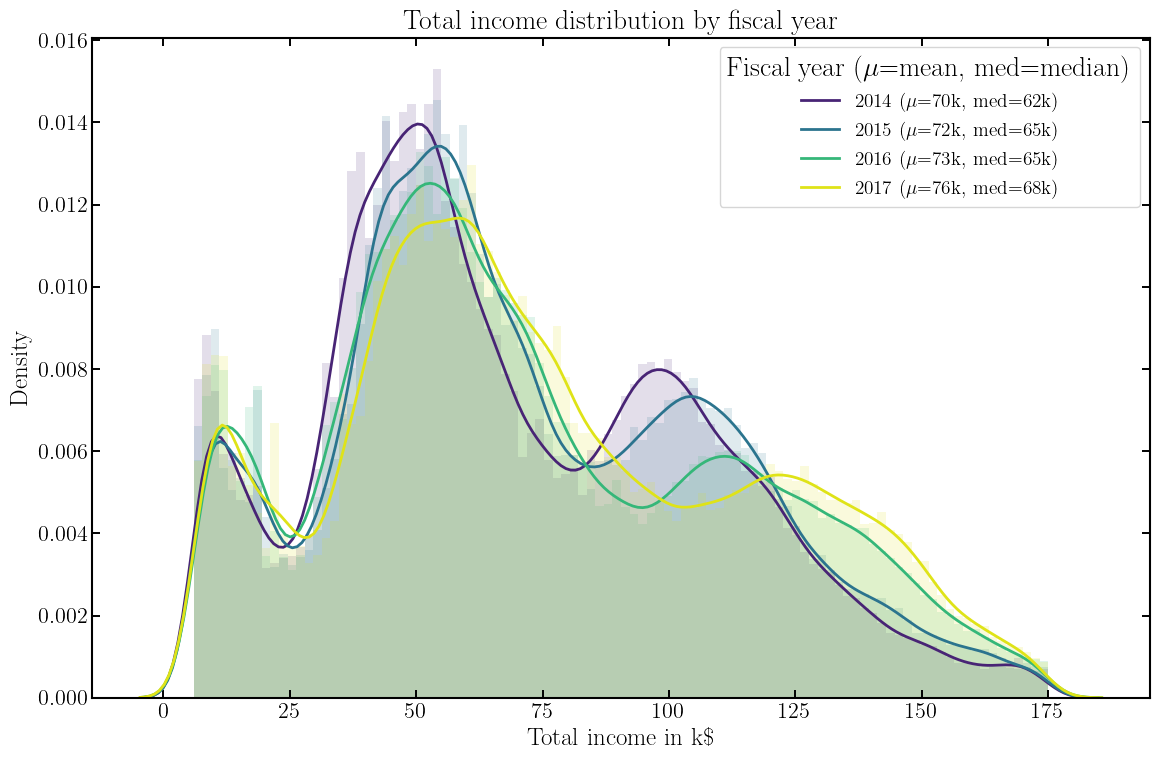

In [4]:
years = sorted(df['fiscal_year'].unique())

# discrete colours sampled from viridis
cmap = plt.cm.viridis
colors = [cmap(i) for i in np.linspace(0.1, 0.95, len(years))]

plt.figure(figsize=(12, 8))

# Store handles for legend
legend_handles = []

for y, c in zip(years, colors):
    subset = df[df['fiscal_year'] == y]['total_income_k']
        
    # Plot histogram 
    plt.hist(subset, bins=100, density=True, alpha=0.15, color=c)
    
    # Plot KDE and store the line object for legend
    kde_line = sns.kdeplot(subset, color=c, linewidth=2, label=f"{y}  ($\mu$={subset.mean():.0f}k, med={subset.median():.0f}k)")
    legend_handles.append(kde_line)

plt.xlabel("Total income in k\$")
plt.ylabel("Density")
plt.title("Total income distribution by fiscal year")
plt.legend(title="Fiscal year ($\mu$=mean, med=median)")
plt.tight_layout()
plt.show()

## Salary Distribution Plot - Compare jobs

In [5]:
top_titles = (
    df['title_description']
    .value_counts()
    .head(7)
    .index
)

df_top = df[df['title_description'].isin(top_titles)]
df_top['title_description'].value_counts()

title_description
police officer         95148
correction officer     34502
firefighter            32121
sanitation worker      25486
school safety agent    20422
community associate    19888
sergeant               16908
Name: count, dtype: int64

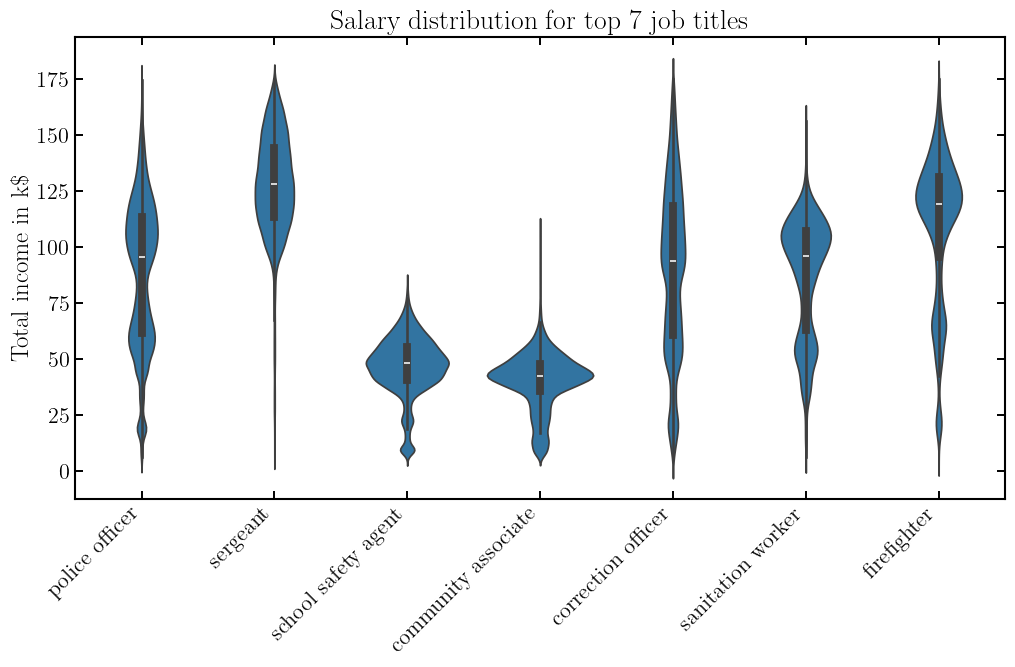

In [6]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df_top,
    x='title_description',
    y='total_income_k'
)

plt.xticks(rotation=45, ha='right')
plt.title("Salary distribution for top 7 job titles")
plt.ylabel("Total income in k\$")
plt.xlabel("")
plt.show()

## Diagnostic plot per work borough

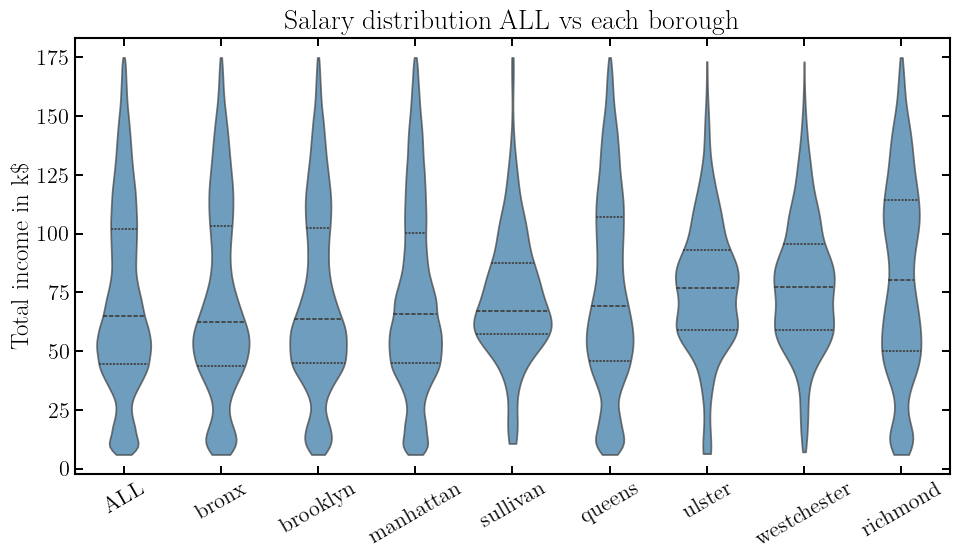

In [7]:
# clean column
df['work_borough'] = (
    df['work_borough']
    .fillna('UNKNOWN')
    .replace('', 'UNKNOWN')  # catch empty strings
)

# get top 8 most frequent (excluding OTHER and UNKNOWN categories)
mask_valid = ~df['work_borough'].isin(['OTHER', 'UNKNOWN'])

top_boroughs = (
    df.loc[mask_valid, 'work_borough']
    .value_counts()
    .head(8)
    .index
)

# group the rest
df['borough_plot'] = df['work_borough'].where(
    df['work_borough'].isin(top_boroughs),
    'Other'
)

# ALL distribution
df_all = df.copy()
df_all['borough_plot'] = 'ALL'

# top boroughs only
df_top = df[df['work_borough'].isin(top_boroughs)].copy()
df_top['borough_plot'] = df_top['work_borough']

# combine
df_plot = pd.concat([df_all, df_top], ignore_index=True)

# order by median income (much more informative)
order_rest = (
    df_top.groupby('borough_plot')['total_income_k']
    .median()
    .sort_values()
    .index
)

order = ['ALL'] + list(order_rest)

plt.figure(figsize=(10,6))

sns.violinplot(
    data=df_plot,
    x='borough_plot',
    y='total_income_k',
    inner='quartile',
    order=order,
    cut=0,
    alpha=0.7
)

plt.xticks(rotation=30)
plt.title("Salary distribution ALL vs each borough")
plt.ylabel("Total income in k\$")
plt.xlabel("")
plt.tight_layout()
plt.show()

## Diagnostic plot of salary vs hours worked

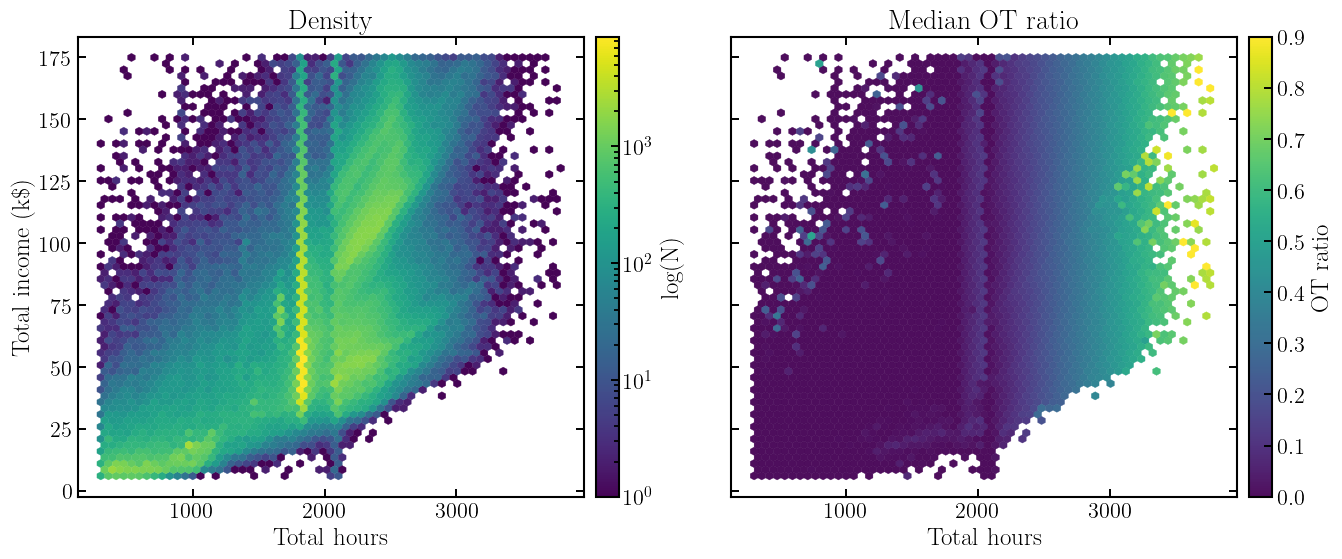

In [8]:
# minimal filtering
df_plot = df[
    (df['total_hours'] < 3800) &
    (df['ot_ratio'].notna())
].copy()

fig, axes = plt.subplots(1, 2, figsize=(14,6), sharex=True, sharey=True)

# =========================
# LEFT: density
# =========================
hb1 = axes[0].hexbin(
    df_plot['total_hours'],
    df_plot['total_income_k'],
    gridsize=60,
    cmap='viridis',
    bins='log',
    alpha=0.99,
    #edgecolors='face',
    linewidths=0.25
)

axes[0].set_title("Density")
axes[0].set_xlabel("Total hours")
axes[0].set_ylabel("Total income (k\$)")

cb1 = fig.colorbar(hb1, ax=axes[0], pad=0.02)
cb1.set_label("log(N)")

# =========================
# RIGHT: OT ratio
# =========================
hb2 = axes[1].hexbin(
    df_plot['total_hours'],
    df_plot['total_income_k'],
    C=df_plot['ot_ratio'],
    reduce_C_function=np.median,
    gridsize=60,
    cmap='viridis',
    vmin=0,
    vmax=0.9,
    alpha=0.95,
    edgecolors='face',
    linewidths=0.25
)

axes[1].set_title("Median OT ratio")
axes[1].set_xlabel("Total hours")

cb2 = fig.colorbar(hb2, ax=axes[1], pad=0.02)
cb2.set_label("OT ratio")

plt.tight_layout()
plt.show()

## Diagnostic plot for job antiquity

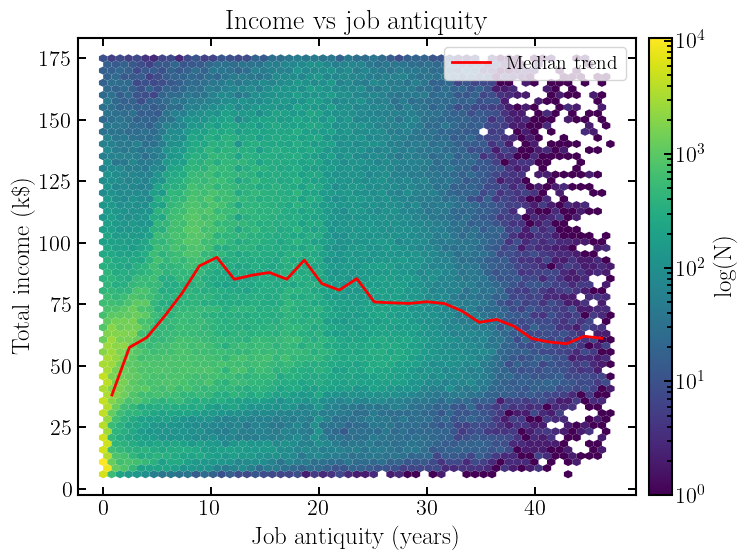

In [9]:
df_plot = df[
    (df['job_antiquity_years'] < 47) &
    (df['total_income_k'] > 0)
].copy()

plt.figure(figsize=(8,6))

hb = plt.hexbin(
    df_plot['job_antiquity_years'],
    df_plot['total_income_k'],
    gridsize=60,
    cmap='viridis',
    bins='log',
    edgecolors='none'
)

# bin antiquity
bins = np.linspace(0, df_plot['job_antiquity_years'].max(), 30)
centers = 0.5 * (bins[:-1] + bins[1:])

median_income = [
    df_plot['total_income_k'][(df_plot['job_antiquity_years'] >= bins[i]) &
             (df_plot['job_antiquity_years'] < bins[i+1])].median()
    for i in range(len(bins)-1)
]

plt.plot(centers, median_income, color='red', lw=2, label='Median trend')
plt.legend()

plt.xlabel("Job antiquity (years)")
plt.ylabel("Total income (k\$)")
plt.title("Income vs job antiquity")

cb = plt.colorbar(hb, pad=0.02)
cb.set_label("log(N)")

plt.tight_layout()
plt.show()

# Machine Learning starts here

## Analyse categories 

In [10]:
# Print 20 most common work_borough
print("=" * 50)
print("10 MOST COMMON WORK_BOROUGH")
print("=" * 50)
print(df['work_borough'].value_counts().head(10))
print("\n")

# Print 20 most common title_description
print("=" * 50)
print("50 MOST COMMON TITLE_DESCRIPTION")
print("=" * 50)
print(df['title_description'].value_counts().head(25))
print("\n")

# Print 20 most common agency_name
print("=" * 50)
print("50 MOST COMMON AGENCY_NAME")
print("=" * 50)
print(df['agency_name'].value_counts().head(25))
print("\n")

# Optional: Also show the number of unique values in each column
print("=" * 50)
print("UNIQUE VALUE COUNTS")
print("=" * 50)
print(f"Unique work_borough: {df['work_borough'].nunique()}")
print(f"Unique title_description: {df['title_description'].nunique()}")
print(f"Unique agency_name: {df['agency_name'].nunique()}")

10 MOST COMMON WORK_BOROUGH
work_borough
manhattan      235892
UNKNOWN        190712
queens         144386
brooklyn       133171
bronx           69117
richmond        19618
westchester      1476
ulster            829
sullivan          377
delaware          257
Name: count, dtype: int64


50 MOST COMMON TITLE_DESCRIPTION
title_description
police officer                        95148
correction officer                    34502
firefighter                           32121
sanitation worker                     25486
school safety agent                   20422
community associate                   19888
sergeant                              16908
clerical associate                    14608
principal administrative associate    13295
caretaker                             12996
p.o. da det gr3                       12131
job training participant              11512
administrative staff analyst          11031
lieutenant                            10906
community coordinator                 10680


In [11]:
# Check the distribution after filtering
print("=" * 50)
print("STEP 1: DEFINE FEATURES AND TARGET")
print("=" * 50)

# Define features and target
features = ['fiscal_year', 'agency_name', 'work_borough', 'title_description', 
            'job_antiquity_years', 'total_hours', 'ot_ratio']
target = 'total_income_k'

X = df[features].copy()
y = df[target].copy()

print("=" * 50)
print("DATA LOADED AND READY")
print("=" * 50)
print(f"Total samples: {len(X):,}")
print(f"Features: {features}")
print(f"Target: {target} (in thousands of $)")
print(f"\nTarget range: {y.min():.1f}k$ to {y.max():.1f}k$")

STEP 1: DEFINE FEATURES AND TARGET
DATA LOADED AND READY
Total samples: 796,275
Features: ['fiscal_year', 'agency_name', 'work_borough', 'title_description', 'job_antiquity_years', 'total_hours', 'ot_ratio']
Target: total_income_k (in thousands of $)

Target range: 6.0k$ to 175.0k$


In [12]:
# Check the distribution after filtering
print("=" * 50)
print("STEP 2: CHECKING CLASS IMBALANCE")
print("=" * 50)

# Check agency distribution
print("\nTop 5 agencies (count and percentage):")
agency_counts = X['agency_name'].value_counts()
agency_pct = X['agency_name'].value_counts(normalize=True) * 100
for agency in agency_counts.head(5).index:
    print(f"  {agency}: {agency_counts[agency]:,} rows ({agency_pct[agency]:.1f}%)")

# Check title distribution
print("\nTop 5 titles (count and percentage):")
title_counts = X['title_description'].value_counts()
title_pct = X['title_description'].value_counts(normalize=True) * 100
for title in title_counts.head(5).index:
    print(f"  {title}: {title_counts[title]:,} rows ({title_pct[title]:.1f}%)")

# Check income stats by agency
print("\nAverage total_income by top agencies:")
for agency in agency_counts.head(5).index:
    avg_income = y[X['agency_name'] == agency].mean()
    print(f"  {agency}: ${avg_income:,.2f}")

STEP 2: CHECKING CLASS IMBALANCE

Top 5 agencies (count and percentage):
  POLICE DEPARTMENT: 212,765 rows (26.7%)
  FIRE DEPARTMENT: 64,865 rows (8.1%)
  HRA/DEPT OF SOCIAL SERVICES: 56,989 rows (7.2%)
  NYC HOUSING AUTHORITY: 46,616 rows (5.9%)
  DEPARTMENT OF EDUCATION ADMIN: 46,387 rows (5.8%)

Top 5 titles (count and percentage):
  police officer: 95,148 rows (11.9%)
  correction officer: 34,502 rows (4.3%)
  firefighter: 32,121 rows (4.0%)
  sanitation worker: 25,486 rows (3.2%)
  school safety agent: 20,422 rows (2.6%)

Average total_income by top agencies:
  POLICE DEPARTMENT: $84.58
  FIRE DEPARTMENT: $98.01
  HRA/DEPT OF SOCIAL SERVICES: $54.13
  NYC HOUSING AUTHORITY: $62.24
  DEPARTMENT OF EDUCATION ADMIN: $62.90


In [13]:
from sklearn.utils import resample

print("=" * 50)
print("STEP 3: FILTER AND BALANCE")
print("=" * 50)

# First, filter to agencies with at least 5,000 employees (so we don't need to oversample)
min_agency_size = 5000
agencies_to_keep = X['agency_name'].value_counts()[X['agency_name'].value_counts() >= min_agency_size].index
print(f"Agencies with >= {min_agency_size} employees: {len(agencies_to_keep)}")

# Filter X and y to only these agencies
X_filtered = X[X['agency_name'].isin(agencies_to_keep)].copy()
y_filtered = y[X_filtered.index].copy()
print(f"After filtering to large agencies: {len(X_filtered):,} rows")

# Now sample equally from each agency (e.g., 3000 per agency)
target_samples_per_agency = 3000
balanced_X_list = []
balanced_y_list = []

for agency in X_filtered['agency_name'].unique():
    agency_mask = X_filtered['agency_name'] == agency
    agency_X = X_filtered[agency_mask]
    agency_y = y_filtered[agency_mask]
    
    # Sample without replacement (all agencies here have >= min_agency_size)
    sampled_idx = resample(agency_X.index, 
                           n_samples=target_samples_per_agency, 
                           random_state=42,
                           replace=False)
    
    balanced_X_list.append(X_filtered.loc[sampled_idx])
    balanced_y_list.append(y_filtered.loc[sampled_idx])

X_balanced = pd.concat(balanced_X_list)
y_balanced = pd.concat(balanced_y_list)

print(f"\nOriginal size: {len(X):,} rows")
print(f"After filtering to large agencies: {len(X_filtered):,} rows")
print(f"Final balanced size: {len(X_balanced):,} rows ({len(X_filtered['agency_name'].unique())} agencies × {target_samples_per_agency} samples)")

# Check new distribution
print("\nNew agency distribution (first 10):")
print(X_balanced['agency_name'].value_counts().head(10))
print(f"\nTotal unique agencies in balanced set: {X_balanced['agency_name'].nunique()}")

STEP 3: FILTER AND BALANCE
Agencies with >= 5000 employees: 21
After filtering to large agencies: 712,906 rows

Original size: 796,275 rows
After filtering to large agencies: 712,906 rows
Final balanced size: 63,000 rows (21 agencies × 3000 samples)

New agency distribution (first 10):
agency_name
POLICE DEPARTMENT                3000
ADMIN FOR CHILDREN'S SVCS        3000
DEPARTMENT OF EDUCATION ADMIN    3000
DEPARTMENT OF FINANCE            3000
DEPARTMENT OF BUILDINGS          3000
DEPARTMENT OF CORRECTION         3000
COMMUNITY COLLEGE (LAGUARDIA)    3000
DEPARTMENT OF SANITATION         3000
DEPT OF CITYWIDE ADMIN SVCS      3000
DEPARTMENT OF TRANSPORTATION     3000
Name: count, dtype: int64

Total unique agencies in balanced set: 21


In [14]:
print("=" * 50)
print("STEP 4: SPLITTING DATA")
print("=" * 50)

# Split into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)

print(f"Training set size: {len(X_train):,} rows")
print(f"Test set size: {len(X_test):,} rows")
print(f"\nTraining set agency distribution (first 5):")
print(X_train['agency_name'].value_counts().head(5))
print(f"\nTest set agency distribution (first 5):")
print(X_test['agency_name'].value_counts().head(5))

STEP 4: SPLITTING DATA
Training set size: 50,400 rows
Test set size: 12,600 rows

Training set agency distribution (first 5):
agency_name
DEPT. OF DESIGN & CONSTRUCTION    2429
DEPT OF HEALTH/MENTAL HYGIENE     2423
DEPT. OF HOMELESS SERVICES        2419
POLICE DEPARTMENT                 2415
FIRE DEPARTMENT                   2414
Name: count, dtype: int64

Test set agency distribution (first 5):
agency_name
DEPT OF ENVIRONMENT PROTECTION    656
LAW DEPARTMENT                    640
DEPT OF INFO TECH & TELECOMM      620
DEPARTMENT OF BUILDINGS           615
NYC HOUSING AUTHORITY             613
Name: count, dtype: int64


In [15]:
print("\n" + "=" * 50)
print("STEP 5: IDENTIFY FEATURE TYPES")
print("=" * 50)

# Define which columns are numerical and which are categorical
numerical_features = ['job_antiquity_years', 'total_hours', 'ot_ratio']
categorical_features = ['fiscal_year', 'agency_name', 'work_borough', 'title_description']

print(f"Numerical features (will be scaled): {numerical_features}")
print(f"Categorical features (will be one-hot encoded): {categorical_features}")
print(f"\nTarget: total_income_k (in thousands of $)")

# Quick check of the data types
print("\nData types:")
print(X_train[numerical_features].dtypes)
print("\nSample of training data:")
print(X_train.head())


STEP 5: IDENTIFY FEATURE TYPES
Numerical features (will be scaled): ['job_antiquity_years', 'total_hours', 'ot_ratio']
Categorical features (will be one-hot encoded): ['fiscal_year', 'agency_name', 'work_borough', 'title_description']

Target: total_income_k (in thousands of $)

Data types:
job_antiquity_years    float64
total_hours            float64
ot_ratio               float64
dtype: object

Sample of training data:
        fiscal_year                     agency_name work_borough  \
324600         2015      DEPT OF PARKS & RECREATION       queens   
139950         2016  DEPT. OF DESIGN & CONSTRUCTION       queens   
80185          2016        DEPARTMENT OF CORRECTION       queens   
336734         2015      DEPT. OF HOMELESS SERVICES     brooklyn   
94176          2016           DEPARTMENT OF FINANCE    manhattan   

                title_description  job_antiquity_years  total_hours  ot_ratio  
324600        community associate             0.000000      1267.00  0.000000  
13995

In [16]:
print("=" * 50)
print("STEP 6: PREPROCESSING PIPELINE")
print("=" * 50)

# Define feature types (matching Step 5)
numerical_features = ['job_antiquity_years', 'total_hours', 'ot_ratio']
categorical_features = ['fiscal_year', 'agency_name', 'work_borough', 'title_description']

print(f"Numerical features (will be scaled): {numerical_features}")
print(f"Categorical features (will be one-hot encoded): {categorical_features}")

# Create preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    ])

# Fit on training data and transform
print("\nFitting preprocessor on training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nShape after preprocessing:")
print(f"  Training set: {X_train_processed.shape}")
print(f"  Test set: {X_test_processed.shape}")

# Show number of features created
n_numerical = len(numerical_features)
n_categorical = X_train_processed.shape[1] - n_numerical
print(f"\nFeature breakdown:")
print(f"  Numerical features (scaled): {n_numerical}")
print(f"  Categorical features (one-hot): {n_categorical}")
print(f"  Total features: {X_train_processed.shape[1]}")

STEP 6: PREPROCESSING PIPELINE
Numerical features (will be scaled): ['job_antiquity_years', 'total_hours', 'ot_ratio']
Categorical features (will be one-hot encoded): ['fiscal_year', 'agency_name', 'work_borough', 'title_description']

Fitting preprocessor on training data...

Shape after preprocessing:
  Training set: (50400, 819)
  Test set: (12600, 819)

Feature breakdown:
  Numerical features (scaled): 3
  Categorical features (one-hot): 816
  Total features: 819


In [17]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "=" * 50)
print("STEP 7: TRAINING RANDOM FOREST")
print("=" * 50)

# Train Random Forest
print("Training Random Forest Regressor (this may take a minute)...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1  # Use all CPU cores
)

rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_train = rf_model.predict(X_train_processed)
y_pred_test = rf_model.predict(X_test_processed)

# Calculate metrics (in k$)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
train_mae = mean_absolute_error(y_train, y_pred_train)
test_mae = mean_absolute_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print("\nModel Performance (in thousands of $):")
print(f"Training Set:")
print(f"  RMSE: {train_rmse:.2f}k$ (${train_rmse*1000:,.0f})")
print(f"  MAE: {train_mae:.2f}k$ (${train_mae*1000:,.0f})")
print(f"  R²: {train_r2:.4f}")
print(f"\nTest Set:")
print(f"  RMSE: {test_rmse:.2f}k$ (${test_rmse*1000:,.0f})")
print(f"  MAE: {test_mae:.2f}k$ (${test_mae*1000:,.0f})")
print(f"  R²: {test_r2:.4f}")
print(f"\nOverfitting gap (Train R² - Test R²): {train_r2 - test_r2:.4f}")


STEP 7: TRAINING RANDOM FOREST
Training Random Forest Regressor (this may take a minute)...

Model Performance (in thousands of $):
Training Set:
  RMSE: 17.37k$ ($17,375)
  MAE: 12.23k$ ($12,232)
  R²: 0.7643

Test Set:
  RMSE: 18.69k$ ($18,693)
  MAE: 13.18k$ ($13,176)
  R²: 0.7290

Overfitting gap (Train R² - Test R²): 0.0353


STEP 8: FEATURE IMPORTANCE ANALYSIS

TOP 13 MOST IMPORTANT FEATURES:
  0.5743 (57.43%) - total_hours
  0.1026 (10.26%) - job_antiquity_years
  0.0323 (3.23%) - title=computer systems manager
  0.0244 (2.44%) - title=assistant corporation counsel
  0.0182 (1.82%) - ot_ratio
  0.0160 (1.60%) - title=administrative staff analyst
  0.0158 (1.58%) - title=administrative engineer
  0.0158 (1.58%) - title=clerical associate
  0.0148 (1.48%) - title=computer specialist
  0.0113 (1.13%) - title=caretaker
  0.0098 (0.98%) - agency=DEPT OF CITYWIDE ADMIN SVCS
  0.0094 (0.94%) - title=community associate
  0.0091 (0.91%) - title=school safety agent


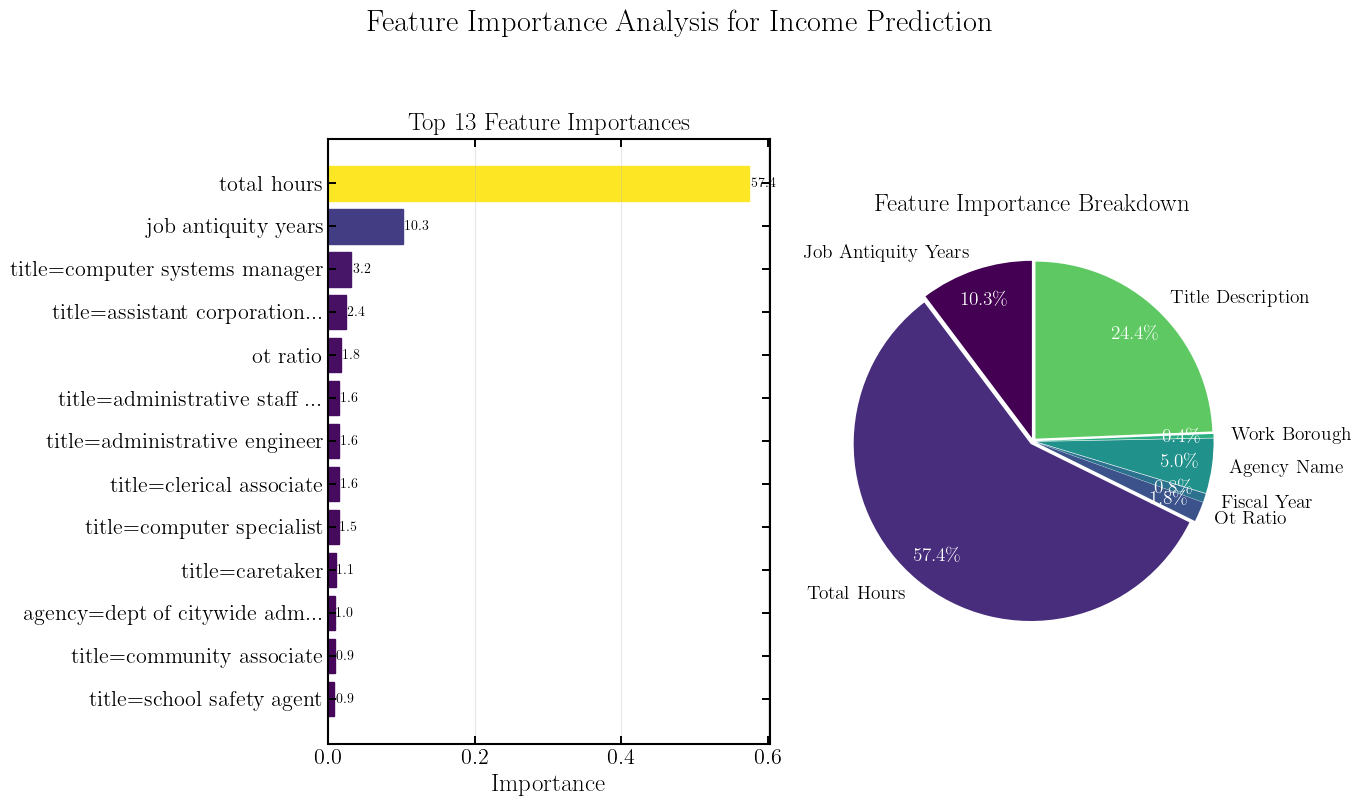


IMPORTANCE BY FEATURE CATEGORY

📊 Numerical features (job_antiquity_years, total_hours, ot_ratio): 69.51%

📊 Categorical features (fiscal_year, agency, borough, title): 30.49%

📊 Breakdown of categorical features:
  • Fiscal Year: 0.79% (top: '2017')
  • Agency Name: 4.99% (top: 'DEPT OF CITYWIDE ADMIN SVCS')
  • Work Borough: 0.35% (top: 'manhattan')
  • Title Description: 24.35% (top: 'computer systems manager')

TOP 10 INDIVIDUAL CATEGORIES (by importance)
   1. 0.0323 (3.23%) - computer systems manager
   2. 0.0244 (2.44%) - assistant corporation counsel
   3. 0.0160 (1.60%) - administrative staff analyst
   4. 0.0158 (1.58%) - administrative engineer
   5. 0.0158 (1.58%) - clerical associate
   6. 0.0148 (1.48%) - computer specialist
   7. 0.0113 (1.13%) - caretaker
   8. 0.0098 (0.98%) - dept of citywide admin svcs
   9. 0.0094 (0.94%) - community associate
  10. 0.0091 (0.91%) - school safety agent


In [22]:
print("=" * 50)
print("STEP 8: FEATURE IMPORTANCE ANALYSIS")
print("=" * 50)

# Get feature names from preprocessor
feature_names = numerical_features.copy()

# Get categorical feature names from one-hot encoder
cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
feature_names.extend(cat_feature_names)

# Get feature importances
importances = rf_model.feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

print("\nTOP 13 MOST IMPORTANT FEATURES:")
print("=" * 50)
for idx, row in feature_importance_df.head(13).iterrows():
    # Clean up the feature name for display
    feature_name = row['feature'].replace('fiscal_year_', 'fiscal_year=')
    feature_name = feature_name.replace('agency_name_', 'agency=')
    feature_name = feature_name.replace('work_borough_', 'borough=')
    feature_name = feature_name.replace('title_description_', 'title=')
    print(f"  {row['importance']:.4f} ({row['importance']*100:.2f}%) - {feature_name}")

# ========== IMPROVED PLOT ==========
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))

# Plot 1: Top 13 features
top_features = feature_importance_df.head(13)

# Clean up feature names for display (lowercase, cleaner)
clean_names = []
for f in top_features['feature'].values:
    # Clean the name
    f_clean = f.lower()
    f_clean = f_clean.replace('fiscal_year_', 'fy=')
    f_clean = f_clean.replace('agency_name_', 'agency=')
    f_clean = f_clean.replace('work_borough_', 'borough=')
    f_clean = f_clean.replace('title_description_', 'title=')
    f_clean = f_clean.replace('_', ' ')
    # Truncate if too long but keep readable
    if len(f_clean) > 30:
        f_clean = f_clean[:27] + '...'
    clean_names.append(f_clean)

bars = ax1.barh(range(len(top_features)), top_features['importance'].values)
ax1.set_yticks(range(len(top_features)))
ax1.set_yticklabels(clean_names)
ax1.set_xlabel('Importance', fontsize=18)
ax1.set_title('Top 13 Feature Importances', fontsize=18, fontweight='bold')
ax1.invert_yaxis()

# Color bars by importance (darker = more important)
colors = plt.cm.viridis(top_features['importance'].values / top_features['importance'].max())
for bar, color in zip(bars, colors):
    bar.set_color(color)

# Add value labels on bars
for i, (idx, row) in enumerate(top_features.iterrows()):
    ax1.text(row['importance'] + 0.002, i, f"{row['importance']*100:.1f}%", 
             va='center', fontsize=10)

ax1.grid(True, alpha=0.3, axis='x')


#---------------------------------------------------------------------------------
# Plot 2: Feature category breakdown
categories = []
category_importances = []

# Add each numerical feature individually
for num_feature in numerical_features:
    # Find the index of this numerical feature
    idx = feature_names.index(num_feature)
    categories.append(num_feature)
    category_importances.append(importances[idx])

# Add each categorical feature group
for cat_feature in categorical_features:
    mask = [f.startswith(cat_feature) for f in feature_names]
    cat_importance = sum(importances[i] for i, m in enumerate(mask) if m)
    categories.append(cat_feature)
    category_importances.append(cat_importance)

# Create pie chart with better labels
cat_labels = [c.replace('_', ' ').title() for c in categories]
# Use a larger color palette since we have more categories
colors_pie = plt.cm.viridis(np.linspace(0.0, 0.75, len(categories)))

# Only explode if we have reasonable number of slices (avoid too many explosions)
explode = [0.02] * len(categories) if len(categories) <= 8 else [0] * len(categories)

wedges, texts, autotexts = ax2.pie(category_importances, 
                                    labels=cat_labels,
                                    autopct='%1.1f%%',
                                    colors=colors_pie,
                                    startangle=90,
                                    explode=explode,
                                    pctdistance=0.82,  # Increased from default 0.6
                                    textprops={'fontsize': 12})

# Style the pie chart text
for text in texts:
    text.set_fontsize(14)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(14)

ax2.set_title('Feature Importance Breakdown', fontsize=18, fontweight='bold')


plt.suptitle('Feature Importance Analysis for Income Prediction', fontsize=22, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "=" * 50)
print("IMPORTANCE BY FEATURE CATEGORY")
print("=" * 50)

numerical_importance = sum(importances[i] for i in range(len(numerical_features)))
print(f"\n📊 Numerical features (job_antiquity_years, total_hours, ot_ratio): {numerical_importance:.2%}")

categorical_importance = 1 - numerical_importance 
print(f"\n📊 Categorical features (fiscal_year, agency, borough, title): {categorical_importance:.2%}")

print("\n📊 Breakdown of categorical features:")
for cat_feature in categorical_features:
    mask = [f.startswith(cat_feature) for f in feature_names]
    cat_importance = sum(importances[i] for i, m in enumerate(mask) if m)
    # Also get top category within this feature
    cat_indices = [i for i, m in enumerate(mask) if m]
    if cat_indices:
        top_idx = max(cat_indices, key=lambda i: importances[i])
        top_value = feature_names[top_idx].replace(cat_feature + '_', '')
        print(f"  • {cat_feature.replace('_', ' ').title()}: {cat_importance:.2%} (top: '{top_value}')")
    else:
        print(f"  • {cat_feature.replace('_', ' ').title()}: {cat_importance:.2%}")

# Optional: Create a horizontal bar chart for top categories
print("\n" + "=" * 50)
print("TOP 10 INDIVIDUAL CATEGORIES (by importance)")
print("=" * 50)

# Get top individual categories (excluding numerical features)
cat_importances_only = [(feature_names[i], importances[i]) for i in range(len(numerical_features), len(feature_names))]
cat_importances_only.sort(key=lambda x: x[1], reverse=True)

for i, (feat, imp) in enumerate(cat_importances_only[:10]):
    # Clean name
    clean_feat = feat.lower()
    for prefix in ['fiscal_year_', 'agency_name_', 'work_borough_', 'title_description_']:
        clean_feat = clean_feat.replace(prefix, '')
    clean_feat = clean_feat.replace('_', ' ')
    print(f"  {i+1:2d}. {imp:.4f} ({imp*100:.2f}%) - {clean_feat}")

STEP 9: ERROR ANALYSIS WITH RELATIVE ERRORS

Prediction Error Statistics:
  Mean absolute error: $13,176
  Mean relative error: 22.8%
  Median relative error: 15.6%
  Max over-prediction: $-73,111 (predicted too high)
  Max under-prediction: $125,033 (predicted too low)

PREDICTION ERROR BY AGENCY (sorted by median relative error):
                                Median Error %  Std Error %  Mean Error %  \
agency                                                                      
DEPT. OF DESIGN & CONSTRUCTION            5.38        25.26          2.03   
DEPARTMENT OF BUILDINGS                   3.17        25.30         -0.42   
DEPARTMENT OF CORRECTION                  3.03        24.66          0.11   
DEPT OF ENVIRONMENT PROTECTION            1.10        28.35         -4.58   
FIRE DEPARTMENT                           0.68        21.05         -3.44   
POLICE DEPARTMENT                         0.39        34.09         -8.38   
DEPARTMENT OF SANITATION                 -0.26    

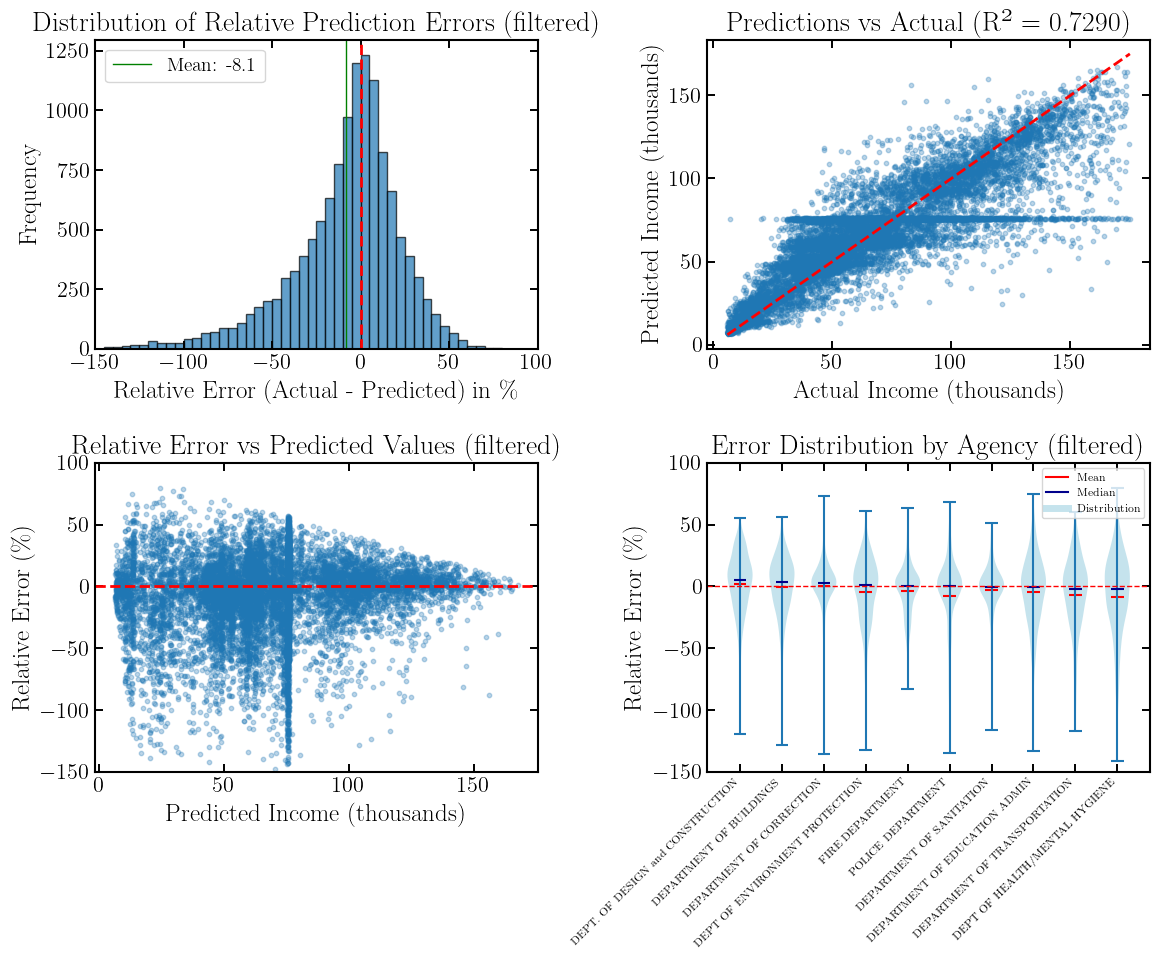


EXTREME OUTLIER ANALYSIS
Number of extreme outliers (|error| > 150%): 26 (0.21%)

Examples of extreme outliers:

  Agency: DEPARTMENT OF CORRECTION
  Title: correction officer
  Actual: $20,907
  Predicted: $75,985
  Relative error: -263.4%

  Agency: COMMUNITY COLLEGE (LAGUARDIA)
  Title: it support assistant
  Actual: $12,351
  Predicted: $33,175
  Relative error: -168.6%

  Agency: DEPARTMENT OF EDUCATION ADMIN
  Title: city elevator operator
  Actual: $18,278
  Predicted: $47,708
  Relative error: -161.0%

  Agency: DEPT. OF HOMELESS SERVICES
  Title: community associate
  Actual: $6,680
  Predicted: $18,514
  Relative error: -177.1%

  Agency: DEPT OF PARKS & RECREATION
  Title: city park worker
  Actual: $46,481
  Predicted: $117,229
  Relative error: -152.2%


In [23]:
print("=" * 50)
print("STEP 9: ERROR ANALYSIS WITH RELATIVE ERRORS")
print("=" * 50)

# Calculate residuals (prediction errors in k$)
residuals = y_test - y_pred_test

# Calculate relative errors (percentage)
relative_errors = (residuals / y_test) * 100

# Create DataFrame with predictions and actual values for analysis
error_df = pd.DataFrame({
    'actual_k': y_test,
    'predicted_k': y_pred_test,
    'residual_k': residuals,
    'relative_error_pct': relative_errors,
    'actual_usd': y_test * 1000,
    'predicted_usd': y_pred_test * 1000,
    'residual_usd': residuals * 1000,
    'agency': X_test['agency_name'],
    'borough': X_test['work_borough'],
    'title': X_test['title_description'],
    'fiscal_year': X_test['fiscal_year']
})

print("\nPrediction Error Statistics:")
print(f"  Mean absolute error: ${abs(residuals).mean()*1000:,.0f}")
print(f"  Mean relative error: {abs(relative_errors).mean():.1f}%")
print(f"  Median relative error: {abs(relative_errors).median():.1f}%")
print(f"  Max over-prediction: ${residuals.min()*1000:,.0f} (predicted too high)")
print(f"  Max under-prediction: ${residuals.max()*1000:,.0f} (predicted too low)")

# Error by agency (using relative errors)
print("\n" + "=" * 50)
print("PREDICTION ERROR BY AGENCY (sorted by median relative error):")
print("=" * 50)
agency_errors = error_df.groupby('agency').agg({
    'relative_error_pct': ['median', 'std', 'mean'],
    'actual_k': 'mean',
    'residual_k': 'mean'
}).round(2)
agency_errors.columns = ['Median Error %', 'Std Error %', 'Mean Error %', 'Avg Income (k$)', 'Mean Bias (k$)']
agency_errors = agency_errors.sort_values('Median Error %', ascending=False)
print(agency_errors.head(10))

# Error by borough
print("\n" + "=" * 50)
print("PREDICTION ERROR BY BOROUGH:")
print("=" * 50)
borough_errors = error_df.groupby('borough').agg({
    'relative_error_pct': ['median', 'mean'],
    'actual_k': 'mean',
    'residual_k': 'mean'
}).round(2)
borough_errors.columns = ['Median Error %', 'Mean Error %', 'Avg Income (k$)', 'Mean Bias (k$)']
print(borough_errors)


# Visualize (with cleaned labels and outlier limits)
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Filter out extreme outliers for better visualization (keep errors between -150% and 100%)
filtered_errors = relative_errors[(relative_errors >= -150) & (relative_errors <= 100)]
filtered_percent = len(filtered_errors) / len(relative_errors) * 100
print(f"Keeping {filtered_percent:.1f}% of data for visualization (errors between -150% and 100%)")

# Relative error distribution (with limits)
axes[0, 0].hist(filtered_errors, bins=50, edgecolor='black', alpha=0.7, range=(-150, 100))
axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Relative Error (Actual - Predicted) in \%')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Relative Prediction Errors (filtered)')
axes[0, 0].axvline(x=filtered_errors.mean(), color='g', linestyle='-', linewidth=1, label=f'Mean: {filtered_errors.mean():.1f}%')
axes[0, 0].legend()
axes[0, 0].set_xlim(-150, 100)

# Predicted vs Actual (in k$)
axes[0, 1].scatter(y_test, y_pred_test, alpha=0.3, s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_xlabel('Actual Income (thousands)')
axes[0, 1].set_ylabel('Predicted Income (thousands)')
axes[0, 1].set_title(f'Predictions vs Actual (R² = {test_r2:.4f})')

# Relative error vs Predicted (with limits)
# Filter for visualization
vis_mask = (relative_errors >= -150) & (relative_errors <= 100)
axes[1, 0].scatter(y_pred_test[vis_mask], relative_errors[vis_mask], alpha=0.3, s=10)
axes[1, 0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Predicted Income (thousands)')
axes[1, 0].set_ylabel('Relative Error (\%)')
axes[1, 0].set_title('Relative Error vs Predicted Values (filtered)')
axes[1, 0].set_ylim(-150, 100)

# Relative error by agency (top 10 agencies by median relative error)
top_agencies = agency_errors.head(10).index
agencies_list = list(top_agencies)

# Clean agency names for display (remove problematic characters)
clean_agency_names = [name.replace('&', 'and') for name in agencies_list]

positions = range(len(agencies_list))

# Filter outliers per agency for boxplot
# Violin plot by agency (top 10 agencies by median relative error)
top_agencies = agency_errors.head(10).index
agencies_list = list(top_agencies)

# Clean agency names for display (remove problematic characters)
clean_agency_names = [name.replace('&', 'and') for name in agencies_list]

positions = range(len(agencies_list))

# Filter outliers per agency for violin plot
filtered_data = []
for agency in agencies_list:
    agency_errors_filtered = error_df[error_df['agency'] == agency]['relative_error_pct']
    agency_errors_filtered = agency_errors_filtered[(agency_errors_filtered >= -150) & (agency_errors_filtered <= 100)]
    filtered_data.append(agency_errors_filtered.dropna())

# Create violin plot
vp = axes[1, 1].violinplot(filtered_data, positions=positions, widths=0.6, showmeans=True, showmedians=True)

# Customize violin plot colors
for pc in vp['bodies']:
    pc.set_facecolor('lightblue')
    pc.set_alpha(0.7)

# Customize mean and median lines
vp['cmeans'].set_color('red')
vp['cmeans'].set_linewidth(1.5)
vp['cmedians'].set_color('darkblue')
vp['cmedians'].set_linewidth(1.5)

# Add horizontal line at zero
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=1)

# Set labels and title
axes[1, 1].set_xticks(positions)
axes[1, 1].set_xticklabels(clean_agency_names, rotation=45, ha='right', fontsize=8)
axes[1, 1].set_ylabel('Relative Error (\%)')
axes[1, 1].set_title('Error Distribution by Agency (filtered)')
axes[1, 1].set_ylim(-150, 100)

# Add legend for mean and median
legend_elements = [Line2D([0], [0], color='red', linewidth=1.5, label='Mean'),
                   Line2D([0], [0], color='darkblue', linewidth=1.5, label='Median'),
                   Line2D([0], [0], color='lightblue', linewidth=5, alpha=0.7, label='Distribution')]
axes[1, 1].legend(handles=legend_elements, loc='upper right', fontsize=8)

plt.tight_layout()
plt.show()

# Also print information about the extreme outliers
print("\n" + "=" * 50)
print("EXTREME OUTLIER ANALYSIS")
print("=" * 50)
extreme_outliers = relative_errors[(relative_errors < -150) | (relative_errors > 100)]
print(f"Number of extreme outliers (|error| > 150%): {len(extreme_outliers)} ({len(extreme_outliers)/len(relative_errors)*100:.2f}%)")

if len(extreme_outliers) > 0:
    print("\nExamples of extreme outliers:")
    extreme_indices = extreme_outliers.head(5).index
    for idx in extreme_indices:
        row = error_df.loc[idx]
        print(f"\n  Agency: {row['agency']}")
        print(f"  Title: {row['title']}")
        print(f"  Actual: ${row['actual_usd']:,.0f}")
        print(f"  Predicted: ${row['predicted_usd']:,.0f}")
        print(f"  Relative error: {row['relative_error_pct']:.1f}%")

In [24]:
print("\n" + "=" * 50)
print("STEP 10: BEST AND WORST PREDICTIONS (by absolute relative error)")
print("=" * 50)

# Calculate absolute relative error
error_df['abs_relative_error_pct'] = abs(error_df['relative_error_pct'])

# Best 3 predictions (smallest absolute relative error)
best_predictions = error_df.nsmallest(3, 'abs_relative_error_pct')
print("\nBEST PREDICTIONS (smallest error percentage):")
for idx, row in best_predictions.iterrows():
    print(f"  {row['title']} at {row['agency']}")
    print(f"    Actual: ${row['actual_usd']:,.0f} | Predicted: ${row['predicted_usd']:,.0f}")
    print(f"    Error: {row['relative_error_pct']:+.1f}% (absolute: {row['abs_relative_error_pct']:.1f}%)")

# Worst 3 predictions (largest absolute relative error)
worst_predictions = error_df.nlargest(3, 'abs_relative_error_pct')
print("\nWORST PREDICTIONS (largest error percentage):")
for idx, row in worst_predictions.iterrows():
    print(f"  {row['title']} at {row['agency']}")
    print(f"    Actual: ${row['actual_usd']:,.0f} | Predicted: ${row['predicted_usd']:,.0f}")
    print(f"    Error: {row['relative_error_pct']:+.1f}% (absolute: {row['abs_relative_error_pct']:.1f}%)")

# Also show breakdown by prediction direction
print("\n" + "=" * 50)
print("ANALYSIS BY PREDICTION DIRECTION")
print("=" * 50)

over_predictions = error_df[error_df['relative_error_pct'] < -50]  # Predicted >50% too high
under_predictions = error_df[error_df['relative_error_pct'] > 50]   # Predicted >50% too low

print(f"\nSevere over-predictions (>50% too high): {len(over_predictions)} cases ({len(over_predictions)/len(error_df)*100:.1f}%)")
print(f"Severe under-predictions (>50% too low): {len(under_predictions)} cases ({len(under_predictions)/len(error_df)*100:.1f}%)")

if len(over_predictions) > 0:
    print("\nExample of severe over-prediction (model said too high):")
    example = over_predictions.iloc[0]
    print(f"  {example['title']} at {example['agency']}")
    print(f"    Actual: ${example['actual_usd']:,.0f} | Predicted: ${example['predicted_usd']:,.0f}")
    print(f"    Model over-predicted by {abs(example['relative_error_pct']):.1f}%")

if len(under_predictions) > 0:
    print("\nExample of severe under-prediction (model said too low):")
    example = under_predictions.iloc[0]
    print(f"  {example['title']} at {example['agency']}")
    print(f"    Actual: ${example['actual_usd']:,.0f} | Predicted: ${example['predicted_usd']:,.0f}")
    print(f"    Model under-predicted by {example['relative_error_pct']:.1f}%")


STEP 10: BEST AND WORST PREDICTIONS (by absolute relative error)

BEST PREDICTIONS (smallest error percentage):
  fraud investigator at DEPT. OF HOMELESS SERVICES
    Actual: $45,225 | Predicted: $45,226
    Error: -0.0% (absolute: 0.0%)
  caretaker at NYC HOUSING AUTHORITY
    Actual: $53,205 | Predicted: $53,203
    Error: +0.0% (absolute: 0.0%)
  principal administrative associate at HRA/DEPT OF SOCIAL SERVICES
    Actual: $56,990 | Predicted: $56,987
    Error: +0.0% (absolute: 0.0%)

WORST PREDICTIONS (largest error percentage):
  sanitation worker at DEPARTMENT OF SANITATION
    Actual: $7,188 | Predicted: $75,494
    Error: -950.3% (absolute: 950.3%)
  sanitation worker at DEPARTMENT OF SANITATION
    Actual: $20,146 | Predicted: $75,695
    Error: -275.7% (absolute: 275.7%)
  correction officer at DEPARTMENT OF CORRECTION
    Actual: $20,907 | Predicted: $75,985
    Error: -263.4% (absolute: 263.4%)

ANALYSIS BY PREDICTION DIRECTION

Severe over-predictions (>50% too high): 12